# Sentiment Analysis: Deep Dive into Twitter Data

### Notebook 4: Neural Network and Performace Evaluation

In this fourth notebook of the Sentiment Analysis project utilizing the Twitter Dataset, our primary focus will be on building, training, and evaluating neural networks for sentiment classification. Using the PyTorch library, we will construct a neural network that will be trained on our training dataset and continuously assessed using validation data. To streamline the process, we will employ MLflow to monitor various hyperparameters of the models. This will help us identify the model with the lowest test loss. Finally, we will use this optimal model to evaluate its performance on the test data within this notebook.

## Importing Libraries and Dependencies

In [3]:
# Importing libraires for file and time operations
import os
import time
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module="mlflow")

# Library for random number generation and iteration
import random
from itertools import product
from tqdm import tnrange,tqdm

# Basic libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

# machine learning libraries using Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

# libraries for Word2Vec using gensim
import gensim
from gensim.models import Word2Vec

# libraries for nltk
import nltk
from nltk.tokenize import WhitespaceTokenizer

# Libraries for Deep Learning with PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
import torch.nn as nn
import torch.nn.functional as F

# Libraries for model evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Library for clearing Jupyter Notebook cell output
from IPython.display import clear_output

# library for experiment tracking using MLFlow
import mlflow
import mlflow.pytorch

## Setting seeds for reporducibility 

Setting seeds is a crucial step in ensuring reproducibility in deep learning experiments. By fixing the random seed for libraries like NumPy, PyTorch, and Python's built-in random module, we can control the randomness in weight initialization, data shuffling, and other stochastic processes. This ensures that the results remain consistent across multiple runs, allowing for fair comparisons and reliable experimentation.


In [ ]:
def set_seed(seed_value):
    
  # python random seed
  random.seed(seed_value)
    
  # numpy random seed
  np.random.seed(seed_value)

  os.environ['PYTHONHASHSEED'] = str(seed_value)

  # Pytorch CPU seed
  torch.manual_seed(seed_value)

  # CuDNN deterministic mode
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

  # generator for torch
  generator = torch.Generator().manual_seed(seed_value)
    
  # PyTorch's GPU seed (if available)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

set_seed(42)

## Load Dataset

In the previous notebook (Notebook 1), we performed text pre-processing and cleaned the Twitter dataset. Now, we will import the saved pre-processed dataset into memory for further use.

The current dataset consists of 1.6 million tweets, which is quite large for training an Artificial Neural Network (ANN) model efficiently. To simplify the process and reduce training time, we will randomly select a subset of 200,000 tweets from the complete pre-processed dataset.

This smaller subset will allow us to train and evaluate the ANN model more quickly while still maintaining a representative sample of the data for sentiment analysis.

In [7]:
# Load the dataset
dataset_1 = pd.read_csv('training_processed_data_final_notebook1.csv')
dataset = dataset_1.sample(200000, random_state = random_seed)
dataset.sample(5)

,target,text
1314411,1,skype tegan hmm think djing tonight
864076,1,eagles saturday night well
1417344,1,stuff pepper w spanish rice beef mushroom toma...
77036,0,beach tony julia try call talk answer
783725,1,course not mean need smart life monetise content


We successfully loaded a subset of 200,000 tweets for our analysis, which will be used to train and evaluate the performance of an Artificial Neural Network (ANN) model. This smaller dataset allows us to work more efficiently while still providing a meaningful sample for sentiment analysis using deep learning techniques. By focusing on this subset, we can expedite the training process and evaluate the model's performance effectively.

In [8]:
dataset.target.value_counts()

,count
target,
1,100215
0,99785


After randomly selecting 200,000 tweets from the pre-processed dataset, we achieved a balanced dataset for sentiment classification. This ensures fair representation of both positive and negative sentiments, enabling the ANN model to generalize better and perform accurately.

Dropping any null values in the dataset.

In [9]:
dataset.dropna(axis = 0, how = "any", inplace = True)
dataset.isnull().sum()

,0
target,0
text,0


In [10]:
dataset.info(memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
Index: 199997 entries, 761837 to 592198
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   target  199997 non-null  int64 
 1   text    199997 non-null  object
dtypes: int64(1), object(1)
memory usage: 20.7 MB


In [11]:
dataset['target'].value_counts()

,count
target,
1,100214
0,99783


## Load Pretrained Word2Vec Model

We will use the pre-trained Word2Vec model from Notebook 2 to convert the tweet text into numerical vectors. For now, we will only utilize the CBOW Word2Vec model that we previously trained.

In [12]:
# path to the pre-trained Word2Vec models
cbow_path = '/Models/CBOW_Word2Vec.model'

# Load the custom Word2Vec model in the memory
cbow = Word2Vec.load(cbow_path)

## Setting up the computational Device

In deep learning, especially when working with large datasets, using a GPU can significantly speed up the training process. Before training the neural network, we check if a GPU is available.

If a GPU is detected, it is set as the default device; otherwise, the system defaults to the CPU. The selected device is then used for all subsequent computations and model training. By displaying the chosen device, we can confirm the computational resource being utilized.

In [14]:
# Select GPU if available, otherwise use CPU
if torch.cuda.is_available():
    # GPU selection
    device = torch.device("cuda")
    print(f'There are {torch.cuda.device_count()} GPUs available.')
    print(f"Device select for training : {torch.cuda.get_device_name(0)}")
else:
    # CPU Selection
    device = torch.device("cpu")
    print("No GPU available, using the CPU instead.")

No GPU available, using the CPU instead.


## Pytorch Dataset

In this project, we use `PyTorch Dataset` class to efficiently manage and preprocess our data. It enables us to load and vectorize tweet text on-the-fly during training, ensuring seamless integration with `Word2Vec` embeddings. This approach not only saves memory but also simplifies feeding data into our neural network, making the pipeline more efficient and scalable.

For tokenizing the text, we will use the `WhitespaceTokenizer` from the `NLTK library`.

In [15]:
# initialize the WhitespaceTokenizer() tokenizer
tokenizer = WhitespaceTokenizer()

In [16]:
# Dataset using Pytorch's Dataset Class 
class TwitterDataset(Dataset):
    
    def __init__(self, df,word2vec_model, is_test = False):
        self.df = df
        self.is_test = is_test
        self.word2vec_model = word2vec_model
        
    def __getitem__(self, index):
        tweet_text = self.df.iloc[index]['text']
        
        # tokenizing the text
        tweet_tokens = tokenizer.tokenize(tweet_text)
        
        # vectorizing the text
        word_vectors =[self.word2vec_model.wv[word] for word in tweet_tokens if word in self.word2vec_model.wv]
        
        # final input to handle null word_vectors
        if len(word_vectors) == 0:
            input = torch.zeros(200)
        else:
            input = torch.tensor(np.mean(word_vectors, axis =0), dtype = torch.float32)
        
        # target 
        target = torch.tensor([self.df.iloc[index]['target']], dtype = torch.float32)

        return input, target

    def __len__(self):
        return len(self.df)

Using `PyTorch Dataset` class, we created a custom `TwitterDataset` class to vectorize each tweet and its corresponding target label in the dataset.

To handle cases where tokenized words from a tweet (using `WhitespaceTokenizer`) are not found in the `CBOW Word2Vec` model's vocabulary, the class returns a null tensor with the same dimensions as the vocabulary (here, 200).

At the end we are getting a average of all these vectorize text. 

In [17]:
#Experiment

temp_1 = dataset[:5]

temp_2 = TwitterDataset(temp_1, word2vec_model = cbow,is_test = False)
print(temp_2[3])

(tensor([ 2.7462e-01, -5.0887e-02,  1.1921e-01,  5.5619e-01, -1.5360e-01,
         2.1961e-01,  1.8041e-01,  1.2228e-01,  8.4924e-01, -7.0661e-01,
         1.3601e+00,  2.9672e-01,  5.9314e-01, -7.1271e-02, -6.3998e-01,
         6.5744e-01,  6.0134e-01, -7.5350e-01, -1.0572e+00,  3.3950e-01,
         1.7680e-01,  6.9885e-01,  4.5522e-01,  8.8731e-01, -2.8162e-01,
         4.3196e-01,  9.9608e-02, -5.3226e-01,  9.8344e-01, -2.4451e-01,
         4.5927e-01,  5.0133e-01, -4.4593e-01, -5.6595e-01,  1.8570e-01,
         5.2763e-01, -7.3352e-01, -8.9741e-01,  5.4429e-01,  5.2878e-01,
         2.5029e-01, -5.9460e-01, -3.5946e-01,  5.3011e-01,  1.6065e-01,
         6.1253e-01, -2.7252e-01, -9.6119e-01, -7.2357e-01,  2.0079e-01,
        -8.1878e-01, -3.8372e-01, -9.9971e-02,  6.2546e-02, -3.5893e-01,
        -9.5020e-01,  1.9288e-01, -6.3359e-01, -2.4361e-01, -5.7465e-02,
        -1.0161e+00, -6.5629e-01,  2.8007e-01, -5.1278e-01, -1.5669e-01,
         6.9511e-01, -2.2050e-02,  1.0269e-01, -7.

Above, experiment is to show the output of a tweet in the dataset and we can see that we are successful to vectorize the text in the tweets and get a average of them into a 200 dimensional vector.

## Splitting the data into Train and Test data

To prevent data leakage, we split the dataset into three distinct groups: `training_dataset`, `val_dataset`, and `testing_dataset`. Below are the lengths of each dataset:

In [19]:
# Length of each split
TRAIN_SIZE = int(0.7*len(dataset))
VAL_SIZE = int(0.2*len(dataset))
TEST_SIZE = len(dataset)-TRAIN_SIZE-VAL_SIZE

print(TRAIN_SIZE,VAL_SIZE,TEST_SIZE)

139997 39999 20001


In [20]:
# Step 1: Split into train and temp (val + test)
train_dataset_split, temp_df = train_test_split(dataset, test_size=(VAL_SIZE + TEST_SIZE), random_state=42, shuffle=True)

# Step 2: Split temp into validation and test
val_dataset_split, test_dataset_split = train_test_split(temp_df, test_size=(TEST_SIZE / (VAL_SIZE + TEST_SIZE)), random_state=42, shuffle=True)

# split the dataset into train, validation and testing data
print(len(train_dataset_split), len(val_dataset_split),len(test_dataset_split))

139997 39999 20001


To efficiently handle data batching, shuffling, and parallel loading, we will use `PyTorch DataLoader` along with the `TwitterDataset` to vectorize batches of data.

This ensures optimal memory usage and accelerates the training process, making the pipeline scalable and efficient.

In [21]:
# Pytorch Dataset instances
train_dataset = TwitterDataset(train_dataset_split, word2vec_model = cbow, is_test = False)
val_dataset = TwitterDataset(val_dataset_split, word2vec_model = cbow, is_test = True)
test_dataset = TwitterDataset(test_dataset_split, word2vec_model = cbow, is_test = True)

We will use a `BATCH_SIZE` of `64` to ensure the system can efficiently load and vectorize the data for the next batch during training.

In [22]:
# BATCH_SIZE
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size  = BATCH_SIZE,  num_workers = 2)
val_loader = DataLoader(val_dataset, batch_size  = BATCH_SIZE,  num_workers = 2)
test_loader = DataLoader(test_dataset, batch_size  = BATCH_SIZE,  num_workers = 2)

In [23]:
# Experiment
for inputs, targets in train_loader:
  print(f"size of input {inputs.shape} and target is {targets.shape}")
  break

for inputs, targets in val_loader:
  print(f"size of input {inputs.shape} and target is {targets.shape}")
  break

for inputs, targets in test_loader:
  print(f"size of input {inputs.shape} and target is {targets.shape}")
  break

size of input torch.Size([64, 200]) and target is torch.Size([64, 1])
size of input torch.Size([64, 200]) and target is torch.Size([64, 1])
size of input torch.Size([64, 200]) and target is torch.Size([64, 1])


## Build Nerual Network

In this section, we focus on building and training a basic neural network to establish a foundational model for sentiment analysis. This serves as a benchmark for evaluating more advanced architectures and provides a baseline for understanding the dataset’s structure, key patterns, and overall sentiment distribution. 

By starting with a simple model, we can assess its performance and identify areas for potential improvement in future iterations.

### Setting up the Neural Network Architecture

In this section, the neural network architecture is defined, and functions for training and testing the model are implemented. The `Classifier` class sets up the network layers, while the `train` and `val` functions manage the training and evaluation process. Additionally, `MLflow` is utilized to facilitate the tracking and analysis of the experiments.

In [25]:
# Neural Network Classifier
class Classifier(nn.Module):
    # ANN model structure 
    def __init__(self, input_size = 200, hidden_size_1=128, hidden_size_2 = 64, out_size=1, dropout_prob=0.3):
        super(Classifier, self).__init__()

        self.features = nn.Sequential(
            
            # Hidden Layer 1
            nn.Linear(input_size, hidden_size_1),
            nn.BatchNorm1d(hidden_size_1),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            # Hidden Layer 2
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.BatchNorm1d(hidden_size_2),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
        )

        # Ouptut Layer
        self.out = nn.Linear(hidden_size_2, out_size)
        
    # Forward propagation
    def forward(self, X):
        feature = self.features(X)
        output = self.out(feature)
        return output

Training loop for a single epoch: The `DataLoader` efficiently splits the `training_dataset` into batches, which are then vectorized using the `TwitterDataset` class. These vectorized batches serve as input to the ANN model `Classifier` built earlier, enabling efficient training and optimization.

In [26]:
# Training function for ANN model
def train(train_loader, net, epoch, criterion, optimizer):
    # model in training phase
    net.train()

    # list to store batch loss
    epoch_loss = []

    # Training loop for single epoch
    for batch_idx, batch in enumerate(tqdm(train_loader)):
        # separate data and target
        inputs, target = batch
    
        # Move the data and labels to the chosen device
        inputs , target = inputs.to(device), target.to(device)

        # Forward propagation and compute predictions and loss
        pred = net(inputs)
        loss = criterion(pred,target.float())
        epoch_loss.append(loss.item())

        # Backward propagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # Convert epoch loss to numpy array and compute mean
    epoch_loss = np.array(epoch_loss)
    epoch_loss_avg = epoch_loss.mean()

    print(f"Epoch {epoch}: Average train Loss: {epoch_loss_avg:.4f}")
    
    return epoch_loss_avg

Testing loop for single epoch using `val_loader` created using `Dataloader`

In [27]:
def val(test_loader, net, epoch, criterion):
  # model in evaluation mode
  net.eval()

  # Disable gradient calculation for performance calculation
  with torch.no_grad():
        
    # Initiate loss list to store the loss
    epoch_val_loss = []

    # Iterate through each batch in the test data loader
    for batch_idx, batch in enumerate(tqdm(val_loader)):
        data,target = batch

        # Move data and target to the chosen device
        data, target = data.to(device), target.to(device)

        # Forward pass: compute predictoins and loss
        pred = net(data)
        loss = criterion(pred, target.float())
        epoch_val_loss.append(loss.item())

    #Convert the epoch loss to numpy array and compute the mean
    epoch_val_loss = np.asarray(epoch_val_loss)
    epoch_val_loss_avg = epoch_val_loss.mean()

    print(f"Epoch {epoch}: Average test Loss: {epoch_val_loss_avg:.4f}")

    return epoch_val_loss_avg

This is the main training function for training the `Classifier` ANN model over `500 epochs`. The model architecture consists of an input layer with `input_size = 200` (vector dimensions), a first hidden layer with `hidden_size_1 = 128`, and a second hidden layer with `hidden_size_2 = 64`.

We utilize `MLflow` to track input parameters and different hyperparameter configurations from the param_grid defined below. This allows us to store the best model for each hyperparameter setting and compare them efficiently.

The model is trained using `BCEWithLogitsLoss` as the loss function and `AdamW` as the optimizer to ensure effective learning.

After training the `Classifier ANN model` across different hyperparameter settings, we load the best-performing model for each configuration and evaluate its performance on the test dataset using `test_dataloader`.

In [28]:
# Main function to train the neural network
def train_nn( args, hidden_size_1 = 128, hidden_size_2 = 64, input_size = 200, output_size = 1):
    # Start MLflow run for experiment tracking
    with mlflow.start_run(experiment_id=experiment_id):
        # Log hyperparameters
        for key, value in args.items():
            mlflow.log_param(key, value)

        # Log neural network architecture details
        mlflow.log_param('input_size', input_size)
        mlflow.log_param('hidden_size_1', hidden_size_1)
        mlflow.log_param('hidden_size_2', hidden_size_2)
        mlflow.log_param('output_size', output_size)

        # initiating the Classifer ANN Model
        net = Classifier(input_size, hidden_size_1, hidden_size_2, output_size)
        
        net.to(device)

        # Defines the loss function
        criterion = nn.BCEWithLogitsLoss()
        
        # Adam optimizer
        optimizer = optim.AdamW(net.parameters(), lr=args['lr'], weight_decay=args['weight_decay'])

        # Initializes variables to keep track of losses and other metrics
        train_losses, test_losses = [], []
        best_test_loss = float('inf')
        best_model_epoch = -1
        no_improvement_epochs = 0

        # start time of model training
        start_time = time.time()

        # Main training loop
        for epoch in range(args['num_epochs']):
            print('Training neural network... Epoch ' + str(epoch) + '/' + str(args['num_epochs']-1))
            if best_model_epoch!=-1:
                print("Best test loss epoch: " + str(best_model_epoch))

            # Training the network and logging the loss
            epoch_train_loss = train(train_loader, net, epoch,criterion, optimizer)
            train_losses.append(epoch_train_loss)
            mlflow.log_metric("epoch_train_loss", epoch_train_loss, step=epoch)

            # Validating the neural network and logging the loss
            epoch_test_loss = val(test_loader, net, epoch, criterion)
            test_losses.append(epoch_test_loss)

            # Checks for improvements in test loss
            dif = best_test_loss - epoch_test_loss
            if epoch_test_loss < best_test_loss:
                best_test_loss = epoch_test_loss
                # Save the state of the best model for future reference
                torch.save(net.state_dict(), 'backup_best_model.pth')
                mlflow.log_metric("best_test_loss_so_far", best_test_loss, step=epoch)
                best_model_epoch = epoch

            # early stopping based on a predefined tolerance and patience
            if dif > args['tolerance']:
                no_improvement_epochs = 0
            else:
                no_improvement_epochs += 1
            if no_improvement_epochs >= args['patience']:
                print("Early stopping at epoch: ", epoch)
                break

        # Records the time at which training ends and calculates the duration
        end_time = time.time()
        duration = end_time - start_time

        # Clears the output and prints the final training status
        # clear_output(wait=True)
        print("Neural network training has finished. Elapsed Time: {:.2f} seconds.".format(duration))
        print("Best model saved.")
        print("Best test loss epoch: " + str(best_model_epoch))

        # Loads the best model
        true_test_labels, predicted_test_labels = [], []
        net.load_state_dict(torch.load("backup_best_model.pth"))

        # Uses the best model to make predictions on the test data
        with torch.no_grad():
            for batch in test_loader:
                dado, rotulo = batch
                dado, rotulo = dado.to(device), rotulo.to(device)
                pred = net(dado)
                true_test_labels.extend(rotulo.detach().cpu().numpy())
                predicted_test_labels.extend((torch.sigmoid(pred) > 0.5).detach().cpu().numpy())
            # Calculates performance metrics and logs them using MLflow
            test_accuracy = accuracy_score(true_test_labels, predicted_test_labels)
            test_precision = precision_score(true_test_labels, predicted_test_labels)
            test_recall = recall_score(true_test_labels, predicted_test_labels)
            test_f1 = f1_score(true_test_labels, predicted_test_labels)
            
            # Logging the output and performance results to Mlflow
            mlflow.pytorch.log_model(net, "models")
            mlflow.log_metric("test_accuracy", test_accuracy)
            mlflow.log_metric("test_precision", test_precision)
            mlflow.log_metric("test_recall", test_recall)
            mlflow.log_metric("test_f1", test_f1)
            mlflow.log_metric("duration", duration)

            # Prints the performance metrics of the best model
            print("Best model metrics:")
            print('Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}'.format(test_accuracy, test_precision, test_recall, test_f1))

    return(train_losses, test_losses, best_model_epoch)

## Tracking Model Experiments with MLflow

This section initializes experiment tracking using MLflow. The code ensures that an experiment named `BASIC_NN` is properly set up. If the experiment already exists, its ID is retrieved; otherwise, a new one is created. This setup enables systematic tracking of different model runs, along with their corresponding metrics, parameters, and outcomes.

In [29]:
# Set experiment name for MLflow tracking
experiment_name = "BASIC_NN"

# Check if experiment exists; create it if not
if mlflow.get_experiment_by_name(experiment_name) is None:
    experiment_id = mlflow.create_experiment(experiment_name)
else:
    # Get existing experiment ID
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

## Hyperparameter Grid Setup and Model Training

This section implements a grid search approach to identify the optimal hyperparameter combination for the neural network. By systematically exploring different configurations—including `learning rate(lr)`, `weight decay(weight_decay)`, and `tolerance` method—the model undergoes an exhaustive search across the specified hyperparameter grid. Each configuration's performance is logged, enabling the selection of the most effective setup for achieving optimal model performance.

In [2]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'vectorization': ['cbow'],
    'criterion': ['BCEWithLogitsLoss'],
    'optimizer': ['Adam'],
    'batch_size': [128],
    'num_workers': [8],
    'lr': [0.0001,0.0005,0.001],  
    'weight_decay': [0.0005,0.0001, 0.001 ], 
    'num_epochs': [500],
    'tolerance': [0.0003],
    'patience': [5]
}

# Generate all combinations of hyperparameters for grid search
all_combinations = [dict(zip(param_grid, v)) for v in product(*param_grid.values())]

In [36]:
# Initialize an empty list to store the results
results = []

# Record the start time for the training process
start_time = time.time()

# Loop through each combination of hyperparameters that have not yet been trained
for params in all_combinations:
  # Train the neural network with the given parameters
  # train_losses, test_losses, best_epoch = train_nn(params,hidden_size_1 = 128,hidden_size_2=64,input_size = 200, output_size = 1)
  train_losses, test_losses, best_epoch = train_nn(params)

  # Append the training results to the results list
  results.append({
      'params': params,
      'train_losses': train_losses,
      'test_losses': test_losses,
      'best_epoch': best_epoch
    })

# Record the end time and calculate the total duration
print("\n")
print(f"Models are trained on all the input parameters.......... Elapsed Time is {time.time()-start_time}")

Training neural network... Epoch 0/499


100%|██████████| 2188/2188 [00:45<00:00, 48.15it/s]


Epoch 0: Average train Loss: 0.5600


100%|██████████| 625/625 [00:11<00:00, 53.56it/s]


Epoch 0: Average test Loss: 0.5148
Training neural network... Epoch 1/499
Best test loss epoch: 0


...

Epoch 13: Average train Loss: 0.4702


100%|██████████| 625/625 [00:10<00:00, 58.08it/s]

Epoch 13: Average test Loss: 0.4895
Early stopping at epoch:  13
Neural network training has finished. Elapsed Time: 796.73 seconds.
Best model saved.
Best test loss epoch: 10



<ipython-input-28-28b580c2e55c>:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load("backup_best_model.pth"))
2025/02/23 10:34:22 WARNING mlflo

Best model metrics:
Accuracy: 0.7632, Precision: 0.7699, Recall: 0.7574, F1: 0.7636


Models are trained on all the input parameters.......... Elapsed Time is 10588.75113105774


## Retrieving MLflow Experiment 

In [38]:
# Function to retrieve experiment data from MLflow and format it into a DataFrame
def retrieve_experiments(id):
    # Fetch all runs for the given experiment ID and convert it to a DataFrame
    df = pd.DataFrame(mlflow.search_runs(experiment_ids=[id]))

    # Select and rename the columns of interest
    df = df[['run_id', 'metrics.best_test_loss_so_far', 'metrics.test_accuracy','metrics.test_f1','metrics.test_recall', 'metrics.test_precision',
          'metrics.duration', 'params.vectorization', 'params.lr', 'params.tolerance', 'params.patience','params.weight_decay']]
    df = df.rename(columns={
        'run_id': 'Run ID', 'metrics.best_test_loss_so_far': 'Best Loss', 'metrics.test_accuracy': 'Accuracy', 'metrics.test_f1': 'F1',
        'metrics.test_recall': 'Recall', 'metrics.test_precision': 'Precision', 'metrics.duration': 'Duration', 'params.vectorization': 'Vectorization',
        'params.lr': 'LR', 'params.tolerance': 'Tolerance', 'params.patience': 'Patience', 'params.weight_decay': 'Weight Decay'})
    return df

# Retrieve and display the experiment data, sorted by 'Best Loss'


df_basic = retrieve_experiments(experiment_id)
display(df_basic.sort_values(by='Best Loss', ascending=True))

,Run ID,Best Loss,Accuracy,F1,Recall,Precision,Duration,Vectorization,LR,Tolerance,Patience,Weight Decay
6,363eb1e0c6bc4f7dadd8f4ecffbc1ea5,0.486354,0.766062,0.764009,0.749975,0.778577,1831.142810,cbow,0.0001,0.0003,5,0.001
7,03feda4a823f4a509d8a301b615851bb,0.486999,0.765412,0.763770,0.751064,0.776913,1681.583416,cbow,0.0001,0.0003,5,0.0001
8,9c95ef76071b4bc7888a731c11fa57a3,0.487096,0.766712,0.765810,0.755421,0.776489,1532.642035,cbow,0.0001,0.0003,5,0.0005
3,ac18bc7c9c3849f38320787fae2ddd60,0.487691,0.764762,0.765372,0.759877,0.770946,896.110707,cbow,0.0005,0.0003,5,0.001
5,6be6adc15a29408a9095b65ba635480d,0.488199,0.764462,0.762562,0.749084,0.776535,1006.809914,cbow,0.0005,0.0003,5,0.0005
0,cbb2770a3b314ef2965ac838c5bdba49,0.488359,0.763212,0.763602,0.757402,0.769904,796.730066,cbow,0.001,0.0003,5,0.001
2,2921f31050724d0e8dfb19ffbdb8a710,0.488672,0.766262,0.767286,0.763145,0.771471,1013.659373,cbow,0.001,0.0003,5,0.0005
1,c92f9a9dc669488a899a38b2cb823806,0.488756,0.765712,0.766261,0.760570,0.772037,907.806845,cbow,0.001,0.0003,5,0.0001
4,8c177e0ff16446c3bafaaf947d0b7593,0.489092,0.766062,0.763818,0.749183,0.779036,797.180275,cbow,0.0005,0.0003,5,0.0001


In [2]:
print(f"MLflow experiment ID is {experiment_id} and best run id is:- {df_basic['Run ID'][6]}")

MLflow experiment ID is 920620067775205696 and best run id is:- 363eb1e0c6bc4f7dadd8f4ecffbc1ea5


Loading the best model that we got from training `Classifier ANN` on different hyperparameters using `MLflow` into the memory to test it's performance on the test data.

In [42]:
# best run id from Mlflow
best_run_id = df_basic['Run ID'][6]

# model path stored in mlflow directory
model_path = f"mlruns/{experiment_id}/{best_run_id}/artifacts/models"

# load the model
model = mlflow.pytorch.load_model(model_path)

# model in evaluation mode
model.eval()

Best Model ID is cbb2770a3b314ef2965ac838c5bdba49


Classifier(
  (features): Sequential(
    (0): Linear(in_features=200, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
  )
  (out): Linear(in_features=64, out_features=1, bias=True)
)

In [43]:
 # list to store true and predicted values
true_test_labels, predicted_test_labels = [], []

# move model to selected device
model.to(device)

# Uses the best model to make predictions on the test data
with torch.no_grad():
    for batch in test_loader:
        inputs, target = batch
        inputs, target = inputs.to(device), target.to(device)
        pred = model(inputs)
        true_test_labels.extend(target.detach().cpu().numpy())
        predicted_test_labels.extend((torch.sigmoid(pred) > 0.5).detach().cpu().numpy())

# Calculates performance metrics and logs them using MLflow
test_report = classification_report(true_test_labels, predicted_test_labels)

# print the classification report for ANN model
print(test_report)

              precision    recall  f1-score   support

         0.0       0.76      0.77      0.76      9902
         1.0       0.77      0.76      0.76     10099

    accuracy                           0.76     20001
   macro avg       0.76      0.76      0.76     20001
weighted avg       0.76      0.76      0.76     20001



We achieved an accuracy of 76% by training the `Classifier ANN` model on a 200,000-sample subset of the complete dataset.


Confusion Matrix:
          Negative  Positive
Negative      7616      2286
Positive      2450      7649


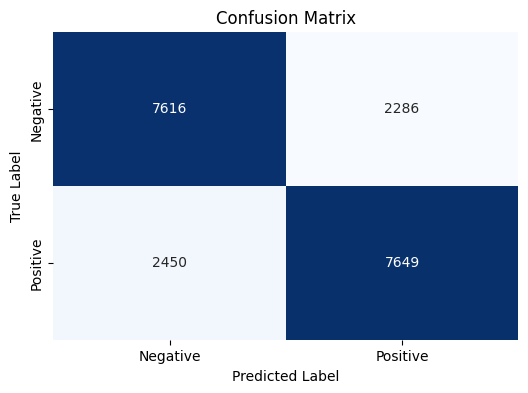

In [44]:
# confusion matrix for the best ANN model
cm = confusion_matrix(true_test_labels, predicted_test_labels)

labels = ["Negative", "Positive"]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("\nConfusion Matrix:")
print(cm_df)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"], cbar = False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Below is the `ROC-AUC` curve for the `Classifier ANN` model obtained after training and hyperparameter tuning.

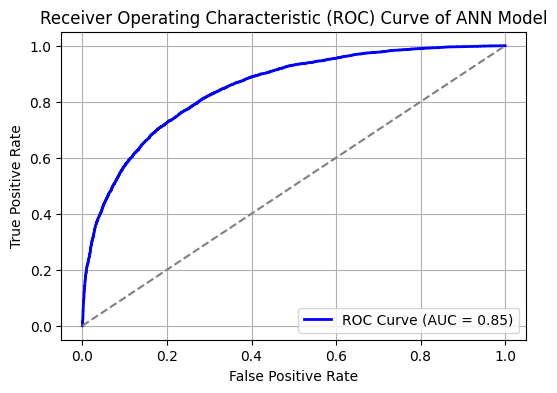

In [49]:
# Ensure model is in evaluation mode
model.eval()

# Lists to store true labels and predicted probabilities
y_true = []
y_probs = []

for inputs, labels in test_loader: 
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)  

    y_true.extend(labels.cpu().numpy())
    y_probs.extend(probs.cpu().numpy())

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)  

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve of ANN Model")
plt.legend(loc="lower right")
plt.grid()
plt.show()